# From Rental Quotes to an Implied Forward Curve

**A 10–15-minute core lesson; extensions are optional.** Our capacity reseller can secure a lower hourly rental price by committing for longer. Its customers may buy only short periods. What do the supplier's package prices imply about the future periods we would be committing to?

By the end, you can recover **implied block rates**, reconstruct package prices, and distinguish an identified block average from an assumed monthly shape. The optional extension adds Notebook 2's discounting.

| Information | What it means |
|---|---|
| Forward quote | A price offered today for a specific future delivery period, subject to its terms. |
| Implied block rate | A calculated allocation of costs from different-length rental contracts that all start today. |

**No supplier has necessarily offered the inferred block separately at that rate.** Even market-based curves can contain inferred or interpolated points; [CME describes this for its valuation curves](https://cmegroupclientsite.atlassian.net/wiki/spaces/EPICSANDBOX/pages/457224064/OTC%2BIRS%2BCurves). Always ask: is this price quoted, inferred, or assumed?

We are examining supplier commitments, not forecasting customer selling prices or calculating resale profit yet.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from liquid_compute.education import show_rental_quotes
from liquid_compute.forward_curves import RentalQuote

# Independent hypothetical supplier menu, not market quotes.
gpu_count = 10
hours_per_month = 720
one_year_usd_per_gpu_hour = 6.00
three_year_usd_per_gpu_hour = 5.00
five_year_usd_per_gpu_hour = 4.40

quotes = (
    RentalQuote(12, one_year_usd_per_gpu_hour),
    RentalQuote(36, three_year_usd_per_gpu_hour),
    RentalQuote(60, five_year_usd_per_gpu_hour),
)
delivery_hours = [hours_per_month] * 60
show_rental_quotes(quotes)

| Contract length (months) | Flat quote (USD/GPU-hour) |
|---:|---:|
| 12 | 6.0000 |
| 36 | 5.0000 |
| 60 | 4.4000 |

### Three packages, one start date

Assume identical GPU specifications, quantity, location, and service. Capacity is constant at 10 GPUs, with 720 delivery hours per GPU per modeled month. We pay for all reserved hours; customer utilization does not reduce this commitment. These are rental rights, not hardware ownership.

Each package starts at time zero and charges its **flat quoted rate throughout**. A 36-month contract at USD 5.00/GPU-hour bills that rate in every month. The inferred allocation below does not replace that invoice schedule.

The bars show contract lengths. Later, the curve will label **delivery periods**: months 1–12, 13–36, and 37–60.

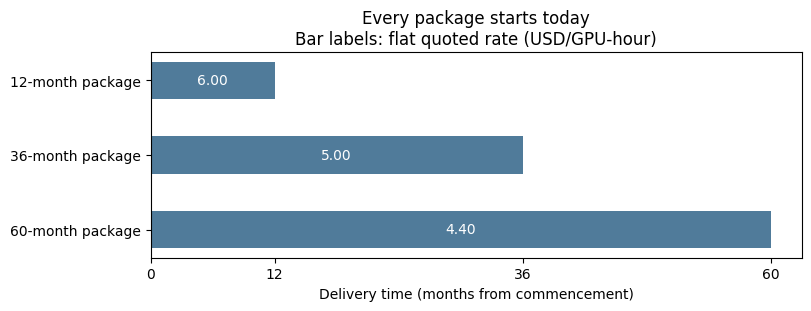

In [3]:
from liquid_compute.education import plot_rental_periods

plot_rental_periods(quotes);

### Subtract the part we can price separately

A three-year package includes the first year. Subtract the separately quoted first year's contribution from the three-year total, then divide the remainder by the hours in years 2–3.

With $N$ GPUs and $h$ equal hours per month, both total costs and remaining hours contain $Nh$, so it cancels:

$$\frac{N(36)h(5.00)-N(12)h(6.00)}{N(24)h}
=\frac{36(5.00)-12(6.00)}{24}=4.50.$$

The first block needs no subtraction: it equals the one-year quote. Repeat the subtraction between the five- and three-year packages to obtain the last block. These are **cost allocations across packages**, not separately purchasable pieces.

In [4]:
# Visible arithmetic before the reusable calculation.
year_one = one_year_usd_per_gpu_hour
years_two_three = (36 * three_year_usd_per_gpu_hour - 12 * year_one) / 24
years_four_five = (
    60 * five_year_usd_per_gpu_hour - 36 * three_year_usd_per_gpu_hour
) / 24
print(f"Months 1–12:  {year_one:.2f} USD/GPU-hour")
print(f"Months 13–36: {years_two_three:.2f} USD/GPU-hour")
print(f"Months 37–60: {years_four_five:.2f} USD/GPU-hour")

Months 1–12:  6.00 USD/GPU-hour
Months 13–36: 4.50 USD/GPU-hour
Months 37–60: 3.50 USD/GPU-hour


### Put the pieces back together

Write the flat whole-contract rate through month $b$ as $R(b)$. The **implied block rate** for service months $a+1$ through $b$ is:

$$F(a,b)=\frac{bR(b)-aR(a)}{b-a}.$$

Handle the first block separately as the shortest quote. This is [Ornn's undiscounted contract-unbundling identity](https://data.ornn.com/docs/forward-curves), applied to our own hypothetical menu.

Reconstruction reverses the operation. Weight each block rate by its duration, add, and divide by the package duration. For three years: $(12\times6+24\times4.5)/36=5$. The table compares reconstructed rates with the original quotes; it does not establish that blocks can be traded separately.

In [5]:
from liquid_compute.education import show_curve_reconstruction
from liquid_compute.forward_curves import imply_rental_blocks

blocks = imply_rental_blocks(quotes, delivery_hours_per_gpu=delivery_hours)
reconstructed_rates = [
    year_one,
    (12 * year_one + 24 * years_two_three) / 36,
    (12 * year_one + 24 * years_two_three + 24 * years_four_five) / 60,
]
show_curve_reconstruction(
    [
        (quote.term_months, quote.rental_usd_per_gpu_hour, recovered)
        for quote, recovered in zip(quotes, reconstructed_rates)
    ]
)

**Rate (USD/GPU-hour)**

| Package months | Original | Reconstructed |
|---:|---:|---:|
| 12 | 6.0000 | 6.0000 |
| 36 | 5.0000 | 5.0000 |
| 60 | 4.4000 | 4.4000 |

### An average is not a monthly price path

The quotes identify an average of USD 4.50 for months 13–36, not a separate rate for every month. For example, both hypothetical allocations below reproduce the same undiscounted block total:

| Allocation | Months 13–24 | Months 25–36 | Average over months 13–36 |
|---|---:|---:|---:|
| Flat | 4.50 | 4.50 | 4.50 |
| Different yearly rates | 3.50 | 5.50 | 4.50 |

All values are USD/GPU-hour. Months 13–15 would have an assigned rate of 4.50 in the first allocation and 3.50 in the second. Using the block average for that quarter requires a **flat-within-block assumption**. Neither allocation is a monthly forecast.

The explorer below uses that flat representation. Change a package price to update the table and curve. It leaves the fixed experiments unchanged. If controls are unavailable, edit the menu above and rerun the cells. A missing quote stays missing: without the 36-month quote, we can infer only one wider months-13–60 block, not two independently identified blocks.

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Current menu | 1–12 | 6.0000 |
| Current menu | 13–36 | 4.5000 |
| Current menu | 37–60 | 3.5000 |


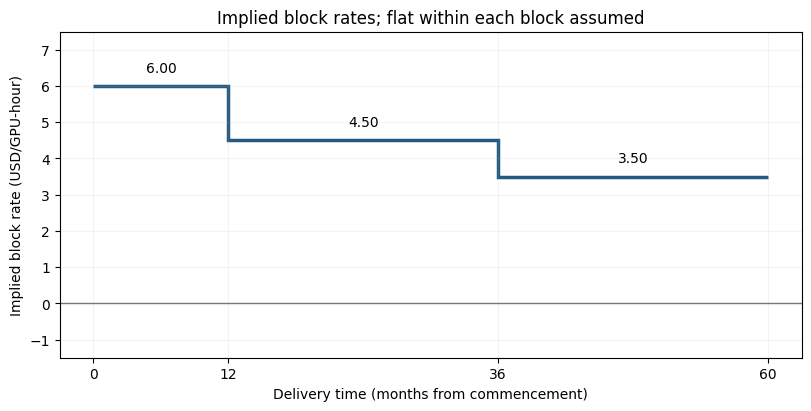

In [6]:
from liquid_compute.education import explore_rental_quotes

explore_rental_quotes(quotes, delivery_hours_per_gpu=delivery_hours);

### Experiment 1 — change only the middle quote

Optional prediction: if the three-year quote rises from 5.00 to 5.20 while the one- and five-year quotes stay fixed, which implied block rates rise or fall?

Use the fixed example below so the comparison stays readable even after changing the explorer. All rates are USD/GPU-hour.

In [7]:
from liquid_compute.education import show_implied_blocks

# Fixed examples, independent of the editable menu.
example_hours = [720] * 60
baseline_quotes = (RentalQuote(12, 6.00), RentalQuote(36, 5.00), RentalQuote(60, 4.40))
raised_middle_quotes = (
    RentalQuote(12, 6.00),
    RentalQuote(36, 5.20),
    RentalQuote(60, 4.40),
)
show_implied_blocks(
    {
        "Baseline": imply_rental_blocks(
            baseline_quotes, delivery_hours_per_gpu=example_hours
        ),
        "Middle quote raised": imply_rental_blocks(
            raised_middle_quotes, delivery_hours_per_gpu=example_hours
        ),
    }
)

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Baseline | 1–12 | 6.0000 |
| Baseline | 13–36 | 4.5000 |
| Baseline | 37–60 | 3.5000 |
| Middle quote raised | 1–12 | 6.0000 |
| Middle quote raised | 13–36 | 4.8000 |
| Middle quote raised | 37–60 | 3.2000 |


**What this shows:** months 13–36 rise from 4.50 to 4.80, while months 37–60 fall from 3.50 to 3.20. The five-year package's total has not changed: allocating more cost to its first three years leaves less for the final two. The first block remains 6.00.

This is the central insight: **the implied block rates are linked by package totals**. A change in one quote can move two inferred blocks in opposite directions.

### Experiment 2 — equal package rates

Optional prediction: what happens if every package costs USD 5.00/GPU-hour, regardless of length?

In [8]:
flat_quotes = tuple(RentalQuote(months, 5.00) for months in (12, 36, 60))
show_implied_blocks(
    {
        "All quotes equal": imply_rental_blocks(
            flat_quotes, delivery_hours_per_gpu=example_hours
        )
    }
)

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| All quotes equal | 1–12 | 5.0000 |
| All quotes equal | 13–36 | 5.0000 |
| All quotes equal | 37–60 | 5.0000 |


**What this shows:** every block is 5.00. With no difference in package rates, allocating cost across delivery periods produces a flat result.

### Experiment 3 — a zero or negative allocation

Optional prediction: keep the first two quotes at 6.00 and 5.00, but reduce the five-year quote to 3.00, then 2.80. What remains after subtracting the three-year package cost?

In [9]:
for five_year_quote in (3.00, 2.80):
    menu = (
        RentalQuote(12, 6.00),
        RentalQuote(36, 5.00),
        RentalQuote(60, five_year_quote),
    )
    show_implied_blocks(
        {
            f"Five-year quote {five_year_quote:.2f}": imply_rental_blocks(
                menu, delivery_hours_per_gpu=example_hours
            )
        }
    )

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Five-year quote 3.00 | 1–12 | 6.0000 |
| Five-year quote 3.00 | 13–36 | 4.5000 |
| Five-year quote 3.00 | 37–60 | 0.0000 |

A zero or negative allocation may reflect package-level discounts. It is not a separately offered price or proof of executable arbitrage.

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Five-year quote 2.80 | 1–12 | 6.0000 |
| Five-year quote 2.80 | 13–36 | 4.5000 |
| Five-year quote 2.80 | 37–60 | -0.5000 |

A zero or negative allocation may reflect package-level discounts. It is not a separately offered price or proof of executable arbitrage.

**What this shows:** the final implied block is zero, then −0.50. At 3.00, the five-year package costs the same in total as the three-year package; at 2.80, it costs less. A longer commitment may attract a discount on the **whole package**, including the overlapping years. A negative leftover allocation does not automatically make the quotes erroneous.

It also does not mean a supplier offers free or negative-priced years 4–5 separately. Check comparability, commitment terms, and what can actually be transacted. [Ornn keeps commercial discounts inside its term marks](https://data.ornn.com/docs/forward-curves); it excludes nonpositive implied stretches from publication. We retain them here to understand the arithmetic, not to claim executable arbitrage.

**Core takeaway:** package quotes determine block averages under stated weights. Monthly shape and executable future prices require additional information. You can now continue to the final takeaway; everything below is optional.

### Optional extension — include payment timing

Use Notebook 2's effective annual rate $r$. Assume every package is paid monthly in arrears at $t_m=m$, with matching payment dates and delivery hours in overlapping months. Let $h_m$ be delivery hours per GPU and $D(t_m)=(1+r)^{-t_m/12}$ the dimensionless discount factor:

$$W(a,b)=\sum_{m=a+1}^{b}h_mD(t_m),\qquad
F_D(a,b)=\frac{R(b)W(0,b)-R(a)W(0,a)}{W(a,b)}.$$

This subtracts package present values and divides by the extra block's discounted hours. Fleet size cancels. **Quoted rates stay unchanged; discounting changes the allocation weights.** The blocks must reproduce every package's PV in USD per GPU:

$$R(T)W(0,T)=\sum_{\text{blocks through }T}F_D(a,b)W(a,b).$$

Zero discounting recovers the original construction with the same hours. This extends the undiscounted identity; it is not a replacement quote.

In [10]:
from math import fsum

from liquid_compute.discounting import discount_factor
from liquid_compute.forward_curves import reconstruct_rental_quotes

# Work one discounted block directly at a hypothetical 12% effective annual rate.
annual_discount_rate = 0.12
factors = [
    discount_factor(annual_discount_rate=annual_discount_rate, months=m)
    for m in range(1, 61)
]
weights = [h * d for h, d in zip(example_hours, factors)]
weighted_middle = (5.00 * fsum(weights[:36]) - 6.00 * fsum(weights[:12])) / fsum(
    weights[12:36]
)
print(f"Months 13–36 at 12%: {weighted_middle:.4f} USD/GPU-hour")

for rate in (0.0, 0.12, 0.24):
    factors = [
        discount_factor(annual_discount_rate=rate, months=m) for m in range(1, 61)
    ]
    weighted_blocks = imply_rental_blocks(
        baseline_quotes,
        delivery_hours_per_gpu=example_hours,
        payment_discount_factors=factors,
    )
    recovered = reconstruct_rental_quotes(
        weighted_blocks,
        delivery_hours_per_gpu=example_hours,
        payment_discount_factors=factors,
    )
    show_implied_blocks({f"Effective annual rate {rate:.0%}": weighted_blocks})
    package_weights = [
        fsum(
            h * d
            for h, d in zip(example_hours[: q.term_months], factors[: q.term_months])
        )
        for q in baseline_quotes
    ]
    show_curve_reconstruction(
        [
            (
                q.term_months,
                q.rental_usd_per_gpu_hour * w,
                rebuilt.rental_usd_per_gpu_hour * w,
            )
            for q, rebuilt, w in zip(baseline_quotes, recovered, package_weights)
        ],
        measure="Present value (USD per GPU)",
    )

Months 13–36 at 12%: 4.4083 USD/GPU-hour


| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Effective annual rate 0% | 1–12 | 6.0000 |
| Effective annual rate 0% | 13–36 | 4.5000 |
| Effective annual rate 0% | 37–60 | 3.5000 |


**Present value (USD per GPU)**

| Package months | Original | Reconstructed |
|---:|---:|---:|
| 12 | 51,840.0000 | 51,840.0000 |
| 36 | 129,600.0000 | 129,600.0000 |
| 60 | 190,080.0000 | 190,080.0000 |

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Effective annual rate 12% | 1–12 | 6.0000 |
| Effective annual rate 12% | 13–36 | 4.4083 |
| Effective annual rate 12% | 37–60 | 3.2020 |


**Present value (USD per GPU)**

| Package months | Original | Reconstructed |
|---:|---:|---:|
| 12 | 48,779.3491 | 48,779.3491 |
| 36 | 109,349.1148 | 109,349.1148 |
| 60 | 144,422.1336 | 144,422.1336 |

| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Effective annual rate 24% | 1–12 | 6.0000 |
| Effective annual rate 24% | 13–36 | 4.3136 |
| Effective annual rate 24% | 37–60 | 2.8442 |


**Present value (USD per GPU)**

| Package months | Original | Reconstructed |
|---:|---:|---:|
| 12 | 46,226.6880 | 46,226.6880 |
| 36 | 94,642.0485 | 94,642.0485 |
| 60 | 115,403.5196 | 115,403.5196 |

**What this shows:** at 12%, the later implied block rates are approximately 4.4083 and 3.2020; at 24%, they are 4.3136 and 2.8442. The quoted packages remain 6.00, 5.00, and 4.40. Each weighted allocation reconstructs those packages' present values, not new contractual invoices.

Do not apply this formula unchanged to packages with different payment structures, such as upfront versus monthly. Discounting does not independently remove commercial, credit, or commitment discounts embedded in the quotes.

### Optional verification — the source's hypothetical example

[Eugene Ye's worked example](https://wafer.substack.com/p/lets-talk-about-trading-compute) uses 6.25 / 4.85 / 4.15 for one, three, and five years, then adds discounting. This is an attributed reproduction, separate from our main menu.

The post assumes **10% continuously compounded**, not 10% effective annual. Its equivalent effective annual rate is `expm1(0.10)`, approximately 10.5171%. That conversion lets us reuse Notebook 2's function. The post's use of the years-2–3 average for months 13–15 also assumes a flat allocation inside the block.

In [11]:
from math import expm1

source_quotes = (RentalQuote(12, 6.25), RentalQuote(36, 4.85), RentalQuote(60, 4.15))
source_effective_rate = expm1(0.10)
source_factors = [
    discount_factor(annual_discount_rate=source_effective_rate, months=m)
    for m in range(1, 61)
]
print(f"10% continuous = {source_effective_rate:.4%} effective annual")
show_implied_blocks(
    {
        "Source, undiscounted": imply_rental_blocks(
            source_quotes, delivery_hours_per_gpu=example_hours
        ),
        "Source, 10% continuous": imply_rental_blocks(
            source_quotes,
            delivery_hours_per_gpu=example_hours,
            payment_discount_factors=source_factors,
        ),
    }
)

10% continuous = 10.5171% effective annual


| Scenario | Delivery months | Implied block rate (USD/GPU-hour) |
|---|---|---:|
| Source, undiscounted | 1–12 | 6.2500 |
| Source, undiscounted | 13–36 | 4.1500 |
| Source, undiscounted | 37–60 | 3.1000 |
| Source, 10% continuous | 1–12 | 6.2500 |
| Source, 10% continuous | 13–36 | 4.0377 |
| Source, 10% continuous | 37–60 | 2.7990 |


The source's undiscounted blocks are 6.25 / 4.15 / 3.10. Its discounted blocks are approximately 6.25 / 4.0377 / 2.7990. Both remain inferred allocations rather than independently offered prices.

### Takeaway and next decision

We can unbundle package totals and put them back together. We cannot infer every month's price, a customer's willingness to pay, or a tradable future offer from those totals alone. Missing quotes stay missing, and a step is an assumed within-block allocation. Our model excludes financing structures, resale profits, options, simulations, and smooth curve fitting.

**References:** [Ornn: undiscounted package unbundling](https://data.ornn.com/docs/forward-curves); [Eugene Ye: worked example and discounted extension](https://wafer.substack.com/p/lets-talk-about-trading-compute); [CME: inferred and interpolated curve points](https://cmegroupclientsite.atlassian.net/wiki/spaces/EPICSANDBOX/pages/457224064/OTC%2BIRS%2BCurves). Our main menu, experiments, and alternate monthly allocations are hypothetical teaching examples.

Next is **Notebook 4 / M1: The Tenor Trade: Buying Long, Selling Short**, the first market-risk lesson. The financing track remains accessible after Notebook 2.

If longer commitments offer a lower hourly rate, what happens when we buy a long contract and resell the capacity in shorter blocks—and what risks do we retain?